In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd


In [2]:
# Load the California Housing dataset
housing = fetch_california_housing(as_frame=True)

# Create a DataFrame from the features and the target variable
df = housing.frame

# Display the first 5 rows of the dataset
print("First 5 rows of the California Housing dataset:")
df.head()

First 5 rows of the California Housing dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
from sklearn.linear_model import LinearRegression


model = LinearRegression()

In [4]:

model.fit(df.drop('MedHouseVal', axis=1), df['MedHouseVal'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


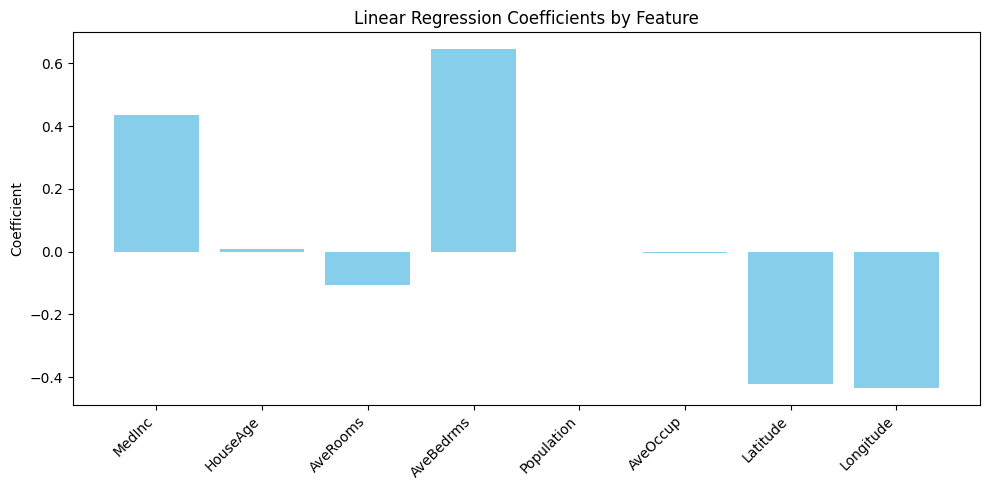

In [8]:
import matplotlib.pyplot as plt

features = df.drop('MedHouseVal', axis=1).columns
coefs = model.coef_

plt.figure(figsize=(10, 5))
plt.bar(features, coefs, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Coefficient')
plt.title('Linear Regression Coefficients by Feature')
plt.tight_layout()
plt.show()

# Classification Model

In [15]:
from sklearn.datasets import load_breast_cancer

cancer_data = load_breast_cancer(as_frame=True)
df_cancer = cancer_data.frame

df_cancer.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [16]:
df_cancer['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [17]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=10000)

log_reg.fit(df_cancer.drop('target', axis=1), df_cancer['target'])



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


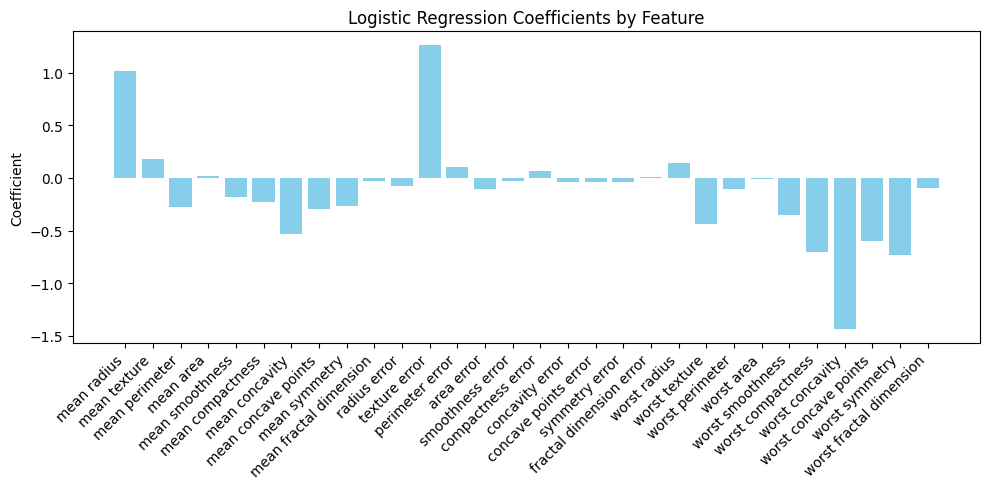

In [18]:
import matplotlib.pyplot as plt

features = df_cancer.drop('target', axis=1).columns
coefs = log_reg.coef_[0]

plt.figure(figsize=(10, 5))
plt.bar(features, coefs, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Coefficient')
plt.title('Logistic Regression Coefficients by Feature')
plt.tight_layout()
plt.show()

In [23]:
import numpy as np
np.round(log_reg.predict_proba(df_cancer.drop('target', axis=1)), 3)

array([[1.   , 0.   ],
       [1.   , 0.   ],
       [1.   , 0.   ],
       ...,
       [0.998, 0.002],
       [1.   , 0.   ],
       [0.   , 1.   ]], shape=(569, 2))

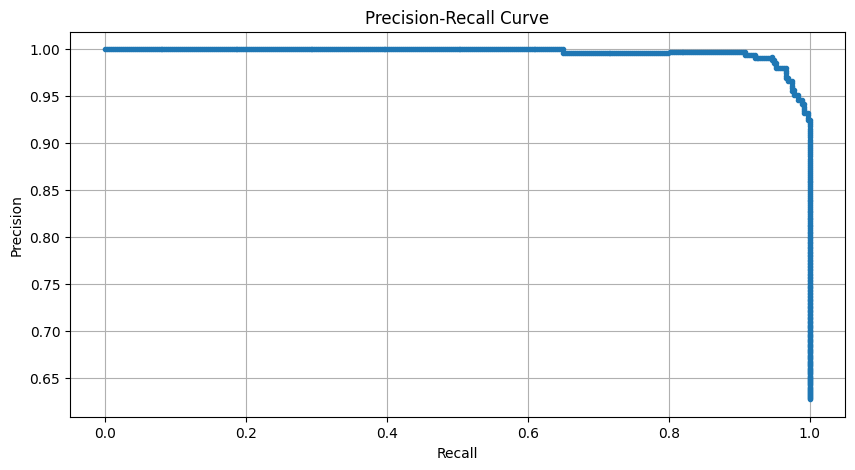

In [24]:
# create precision recall curve

from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(df_cancer['target'], log_reg.predict_proba(df_cancer.drop('target', axis=1))[:, 1])

# plot it

plt.figure(figsize=(10, 5))
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid()
plt.show()

In [25]:
# define a neuron

def neuron(W, X, b, activation='relu'):
    if activation == 'relu':
        return np.maximum(0, np.dot(W, X) + b)
    elif activation == 'sigmoid':
        return 1 / (1 + np.exp(-(np.dot(W, X) + b)))